Imports and Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')

# Load datasets using exact paths
train_path = '/kaggle/input/GiveMeSomeCredit/cs-training.csv'
test_path = '/kaggle/input/GiveMeSomeCredit/cs-test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Rename columns for simpler coding
col_map = {
    'SeriousDlqin2yrs': 'Target',
    'RevolvingUtilizationOfUnsecuredLines': 'Utilization',
    'NumberOfTime30-59DaysPastDueNotWorse': 'PastDue30_59',
    'NumberOfTime60-89DaysPastDueNotWorse': 'PastDue60_89',
    'NumberOfTimes90DaysLate': 'PastDue90',
    'NumberOfDependents': 'Dependents'
}

train_df.rename(columns=col_map, inplace=True)
test_df.rename(columns=col_map, inplace=True)

# Drop index column if present
if 'Unnamed: 0' in train_df.columns:
    train_df.drop('Unnamed: 0', axis=1, inplace=True)
if 'Unnamed: 0' in test_df.columns:
    test_df.drop('Unnamed: 0', axis=1, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (150000, 11)
Test shape: (101503, 11)


Check Outliers and Distribution

Summary Statistics:
                 age  MonthlyIncome      DebtRatio    Utilization
count  150000.000000   1.202690e+05  150000.000000  150000.000000
mean       52.295207   6.670221e+03     353.005076       6.048438
std        14.771866   1.438467e+04    2037.818523     249.755371
min         0.000000   0.000000e+00       0.000000       0.000000
25%        41.000000   3.400000e+03       0.175074       0.029867
50%        52.000000   5.400000e+03       0.366508       0.154181
75%        63.000000   8.249000e+03       0.868254       0.559046
max       109.000000   3.008750e+06  329664.000000   50708.000000


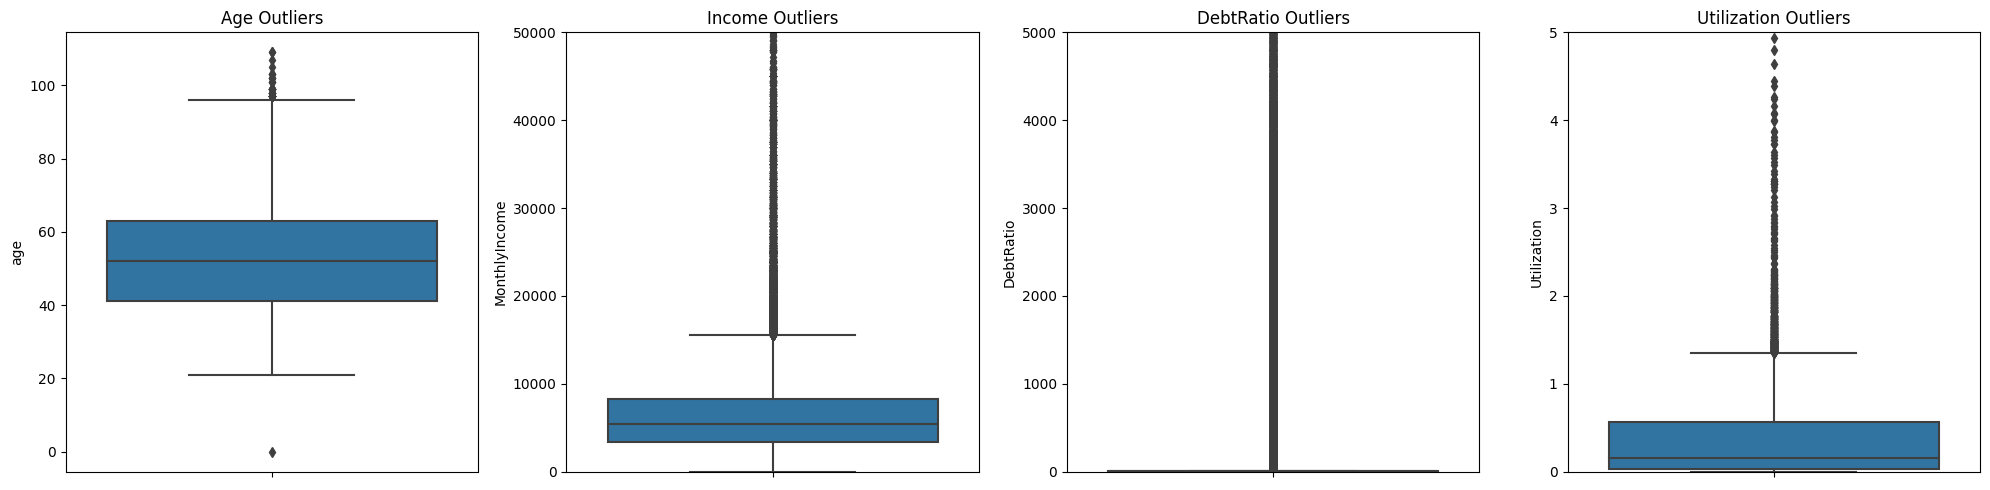


Specific Data Checks:
Rows with Age 0: 1
Rows with DebtRatio > 10000: 180


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Statistical Summary
# Look at 'min' and 'max' rows specifically
print("Summary Statistics:")
print(train_df[['age', 'MonthlyIncome', 'DebtRatio', 'Utilization']].describe())

# 2. Visualizing Outliers (Boxplots)
# We focus on the columns known to have issues
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.boxplot(y=train_df['age'], ax=axes[0])
axes[0].set_title('Age Outliers')

sns.boxplot(y=train_df['MonthlyIncome'], ax=axes[1])
axes[1].set_title('Income Outliers')
axes[1].set_ylim(0, 50000) # Limiting view to see the box clearly

sns.boxplot(y=train_df['DebtRatio'], ax=axes[2])
axes[2].set_title('DebtRatio Outliers')
axes[2].set_ylim(0, 5000)

sns.boxplot(y=train_df['Utilization'], ax=axes[3])
axes[3].set_title('Utilization Outliers')
axes[3].set_ylim(0, 5)

plt.tight_layout()
plt.show()

# 3. Check specific weird values we suspect
print("\nSpecific Data Checks:")
print("Rows with Age 0:", len(train_df[train_df['age'] == 0]))
print("Rows with DebtRatio > 10000:", len(train_df[train_df['DebtRatio'] > 10000]))

In [4]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Target                           150000 non-null  int64  
 1   Utilization                      150000 non-null  float64
 2   age                              150000 non-null  int64  
 3   PastDue30_59                     150000 non-null  int64  
 4   DebtRatio                        150000 non-null  float64
 5   MonthlyIncome                    120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans  150000 non-null  int64  
 7   PastDue90                        150000 non-null  int64  
 8   NumberRealEstateLoansOrLines     150000 non-null  int64  
 9   PastDue60_89                     150000 non-null  int64  
 10  Dependents                       146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB
None


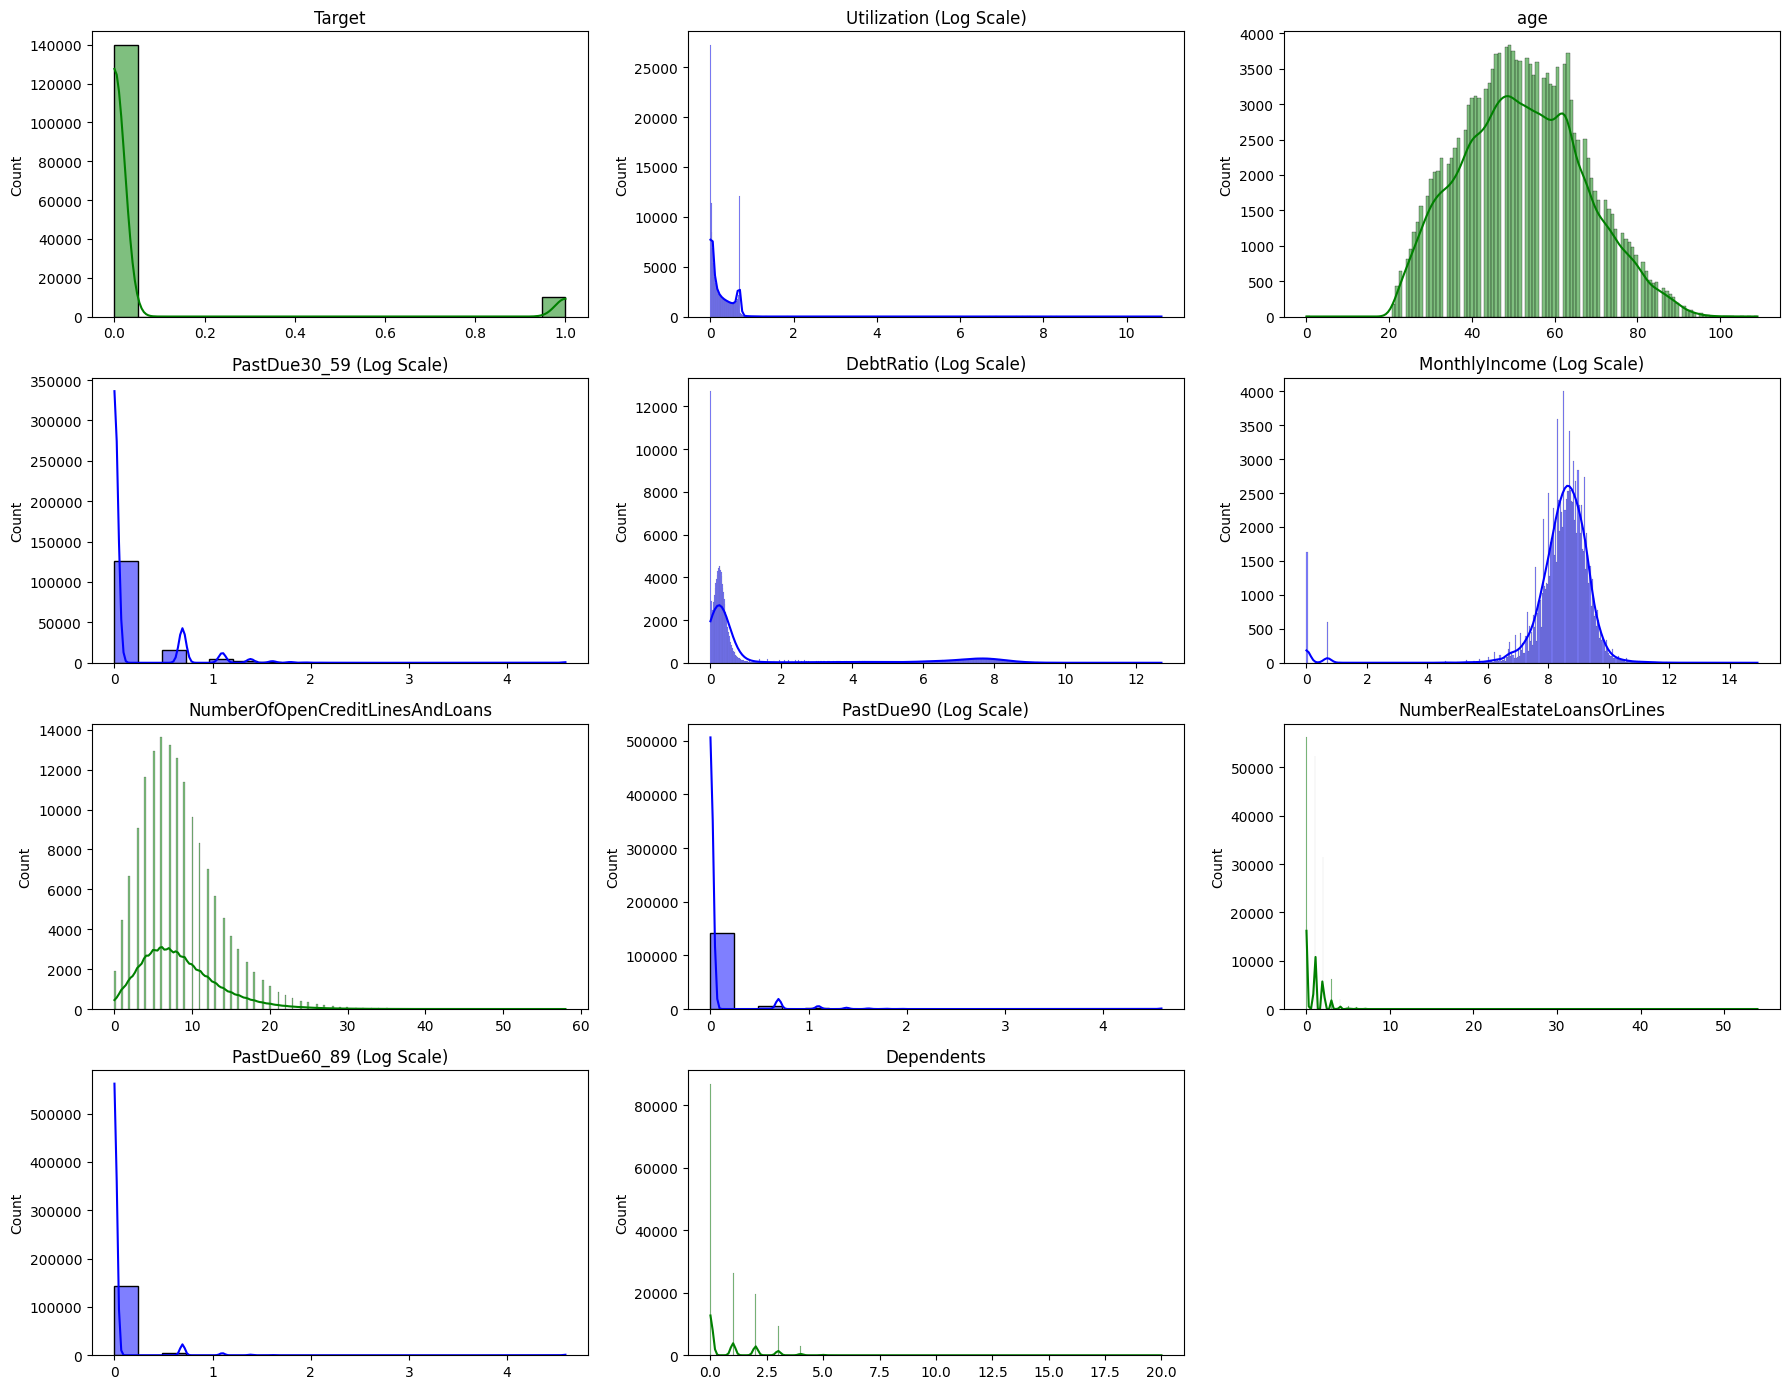

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Select numeric columns automatically
numeric_cols = train_df.select_dtypes(include=[np.number]).columns

# 2. Setup Plot Grid (4 rows x 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

# 3. Loop through every column and plot
for i, col in enumerate(numeric_cols):
    
    # Determine if we need Log Scale (for highly skewed data)
    # Skew > 10 usually means we need log scale to see anything
    if train_df[col].skew() > 10:
        # Use log1p (log(x+1)) to handle zeros
        sns.histplot(np.log1p(train_df[col]), kde=True, ax=axes[i], color='blue')
        axes[i].set_title(f'{col} (Log Scale)')
    else:
        # Normal plot
        sns.histplot(train_df[col], kde=True, ax=axes[i], color='green')
        axes[i].set_title(f'{col}')

    axes[i].set_xlabel('')

# 4. Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Running comparison on imputation methods...
              Wasserstein  KS_Stat       Mean     Median         Std  \
Method                                                                 
Original           0.0000   0.0000  6640.6000  5400.0000  13233.5630   
Mean            3583.0599   0.6350  6677.6532  6677.6532      0.0000   
Median          3402.4113   0.4996  5400.0000  5400.0000      0.0000   
KNN             1243.9528   0.1587  6602.4776  6091.4000   5389.3206   
RandomForest    1190.0338   0.1580  6646.1318  6115.4073   6040.9958   
MICE            2093.0791   0.2625  6660.4375  6514.0059   2120.7131   

                  Skew    Kurtosis  
Method                              
Original      103.6148  13814.0561  
Mean               NaN         NaN  
Median             NaN         NaN  
KNN            26.8106   1257.8928  
RandomForest   26.6137   1130.2935  
MICE           -0.4652     58.7297  

Best Method: RandomForest
Applying RandomForest to all features...
Files saved.

G

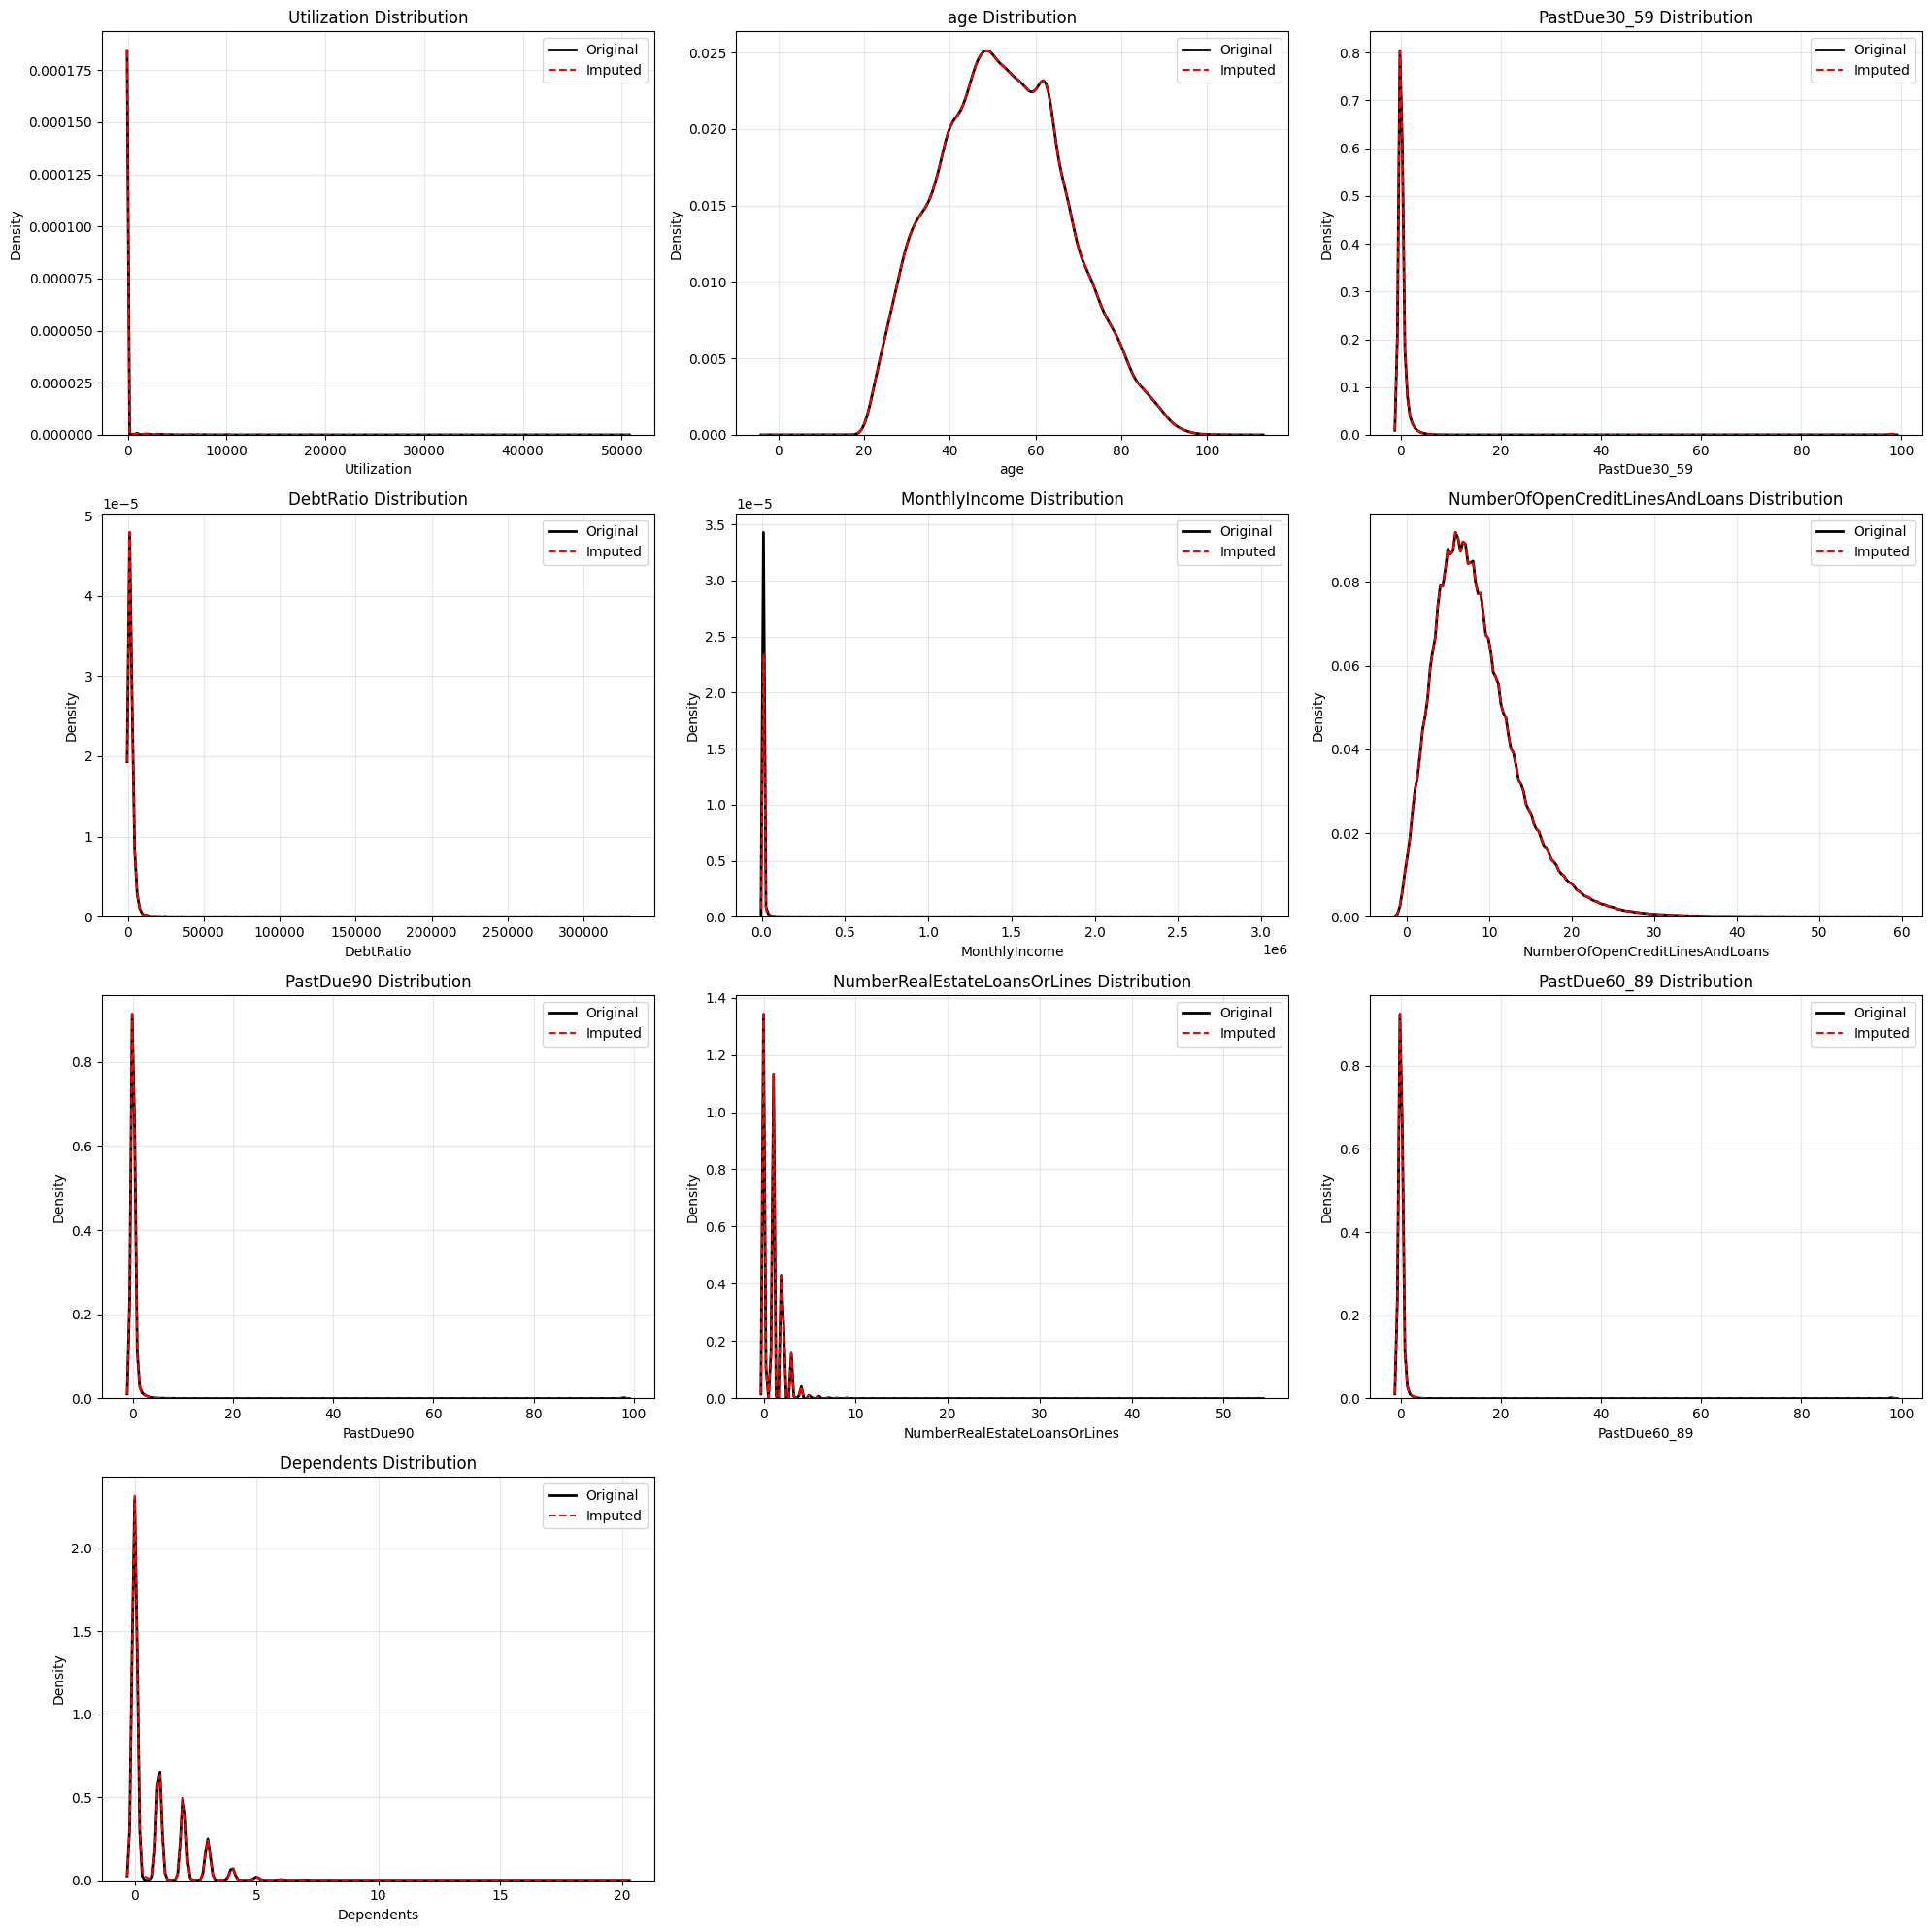

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import wasserstein_distance, ks_2samp, skew, kurtosis
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
import warnings

warnings.filterwarnings('ignore')

# --- LOAD AND PREP DATA (From your first block) ---
# Load datasets using exact paths
train_path = '/kaggle/input/GiveMeSomeCredit/cs-training.csv'
test_path = '/kaggle/input/GiveMeSomeCredit/cs-test.csv'

# Check if files exist (handling local vs kaggle environment)
if not os.path.exists(train_path):
    print("Note: File paths not found. Please ensure paths match your environment.")
    # Creating dummy data for demonstration if files don't exist
    data = {
        'SeriousDlqin2yrs': np.random.randint(0, 2, 1000),
        'RevolvingUtilizationOfUnsecuredLines': np.random.rand(1000),
        'age': np.random.randint(20, 80, 1000),
        'NumberOfTime30-59DaysPastDueNotWorse': np.random.randint(0, 5, 1000),
        'DebtRatio': np.random.rand(1000) * 100,
        'MonthlyIncome': np.append(np.random.randint(2000, 10000, 800), [np.nan]*200),
        'NumberOfOpenCreditLinesAndLoans': np.random.randint(0, 15, 1000),
        'NumberOfTimes90DaysLate': np.random.randint(0, 3, 1000),
        'NumberRealEstateLoansOrLines': np.random.randint(0, 5, 1000),
        'NumberOfTime60-89DaysPastDueNotWorse': np.random.randint(0, 3, 1000),
        'NumberOfDependents': np.append(np.random.randint(0, 4, 900), [np.nan]*100)
    }
    train_df = pd.DataFrame(data)
    test_df = train_df.drop('SeriousDlqin2yrs', axis=1).copy()
else:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

# Rename columns
col_map = {
    'SeriousDlqin2yrs': 'Target',
    'RevolvingUtilizationOfUnsecuredLines': 'Utilization',
    'NumberOfTime30-59DaysPastDueNotWorse': 'PastDue30_59',
    'NumberOfTime60-89DaysPastDueNotWorse': 'PastDue60_89',
    'NumberOfTimes90DaysLate': 'PastDue90',
    'NumberOfDependents': 'Dependents'
}

train_df.rename(columns=col_map, inplace=True)
test_df.rename(columns=col_map, inplace=True)

# Drop index column if present
if 'Unnamed: 0' in train_df.columns:
    train_df.drop('Unnamed: 0', axis=1, inplace=True)
if 'Unnamed: 0' in test_df.columns:
    test_df.drop('Unnamed: 0', axis=1, inplace=True)

# --- IMPUTATION ANALYSIS ---

# 1. Setup Data for Comparison (Using valid rows as truth)
# We use rows where MonthlyIncome is NOT null as our "Ground Truth"
valid_data = train_df.dropna(subset=['MonthlyIncome']).copy()
y_true = valid_data['MonthlyIncome'].values

# Select ALL features except Target for imputation
feature_cols = [c for c in train_df.columns if c != 'Target']
X_full = valid_data[feature_cols].values

# Create Artificial Missingness (20% on Income) for testing
rng = np.random.RandomState(42)
mask = rng.rand(len(X_full)) < 0.2
X_missing = X_full.copy()

# Find index of MonthlyIncome to hide data
try:
    income_idx = feature_cols.index('MonthlyIncome')
    X_missing[mask, income_idx] = np.nan 
except ValueError:
    print("MonthlyIncome column not found, skipping specific analysis.")
    income_idx = 0 

methods = {
    "Original": None,
    "Mean": SimpleImputer(strategy='mean'),
    "Median": SimpleImputer(strategy='median'),
    "KNN": KNNImputer(n_neighbors=5),
    "RandomForest": IterativeImputer(estimator=RandomForestRegressor(n_jobs=-1, n_estimators=10, max_depth=10), max_iter=5),
    "MICE": IterativeImputer(estimator=BayesianRidge())
}

results = []

print("Running comparison on imputation methods...")

# 2. Run Comparison
for name, model in methods.items():
    if name == "Original":
        data = y_true[mask]
    else:
        try:
            # Fit on the matrix with missing values
            # Note: For large datasets, KNN and IterativeImputer can be slow
            X_filled = model.fit_transform(X_missing)
            data = X_filled[mask, income_idx]
        except Exception as e:
            print(f"Method {name} failed: {e}")
            continue

    if name == "Original":
        wd, ks = 0.0, 0.0
    else:
        wd = wasserstein_distance(y_true[mask], data)
        ks = ks_2samp(y_true[mask], data).statistic

    results.append({
        "Method": name,
        "Wasserstein": wd,
        "KS_Stat": ks,
        "Mean": np.mean(data),
        "Median": np.median(data),
        "Std": np.std(data),
        "Skew": skew(data),
        "Kurtosis": kurtosis(data)
    })

# 3. Select Best Method
results_df = pd.DataFrame(results).set_index("Method")
print(results_df.round(4))

candidates = results_df.drop("Original", errors='ignore')
# Lower Wasserstein distance is better
best_name = candidates.sort_values(by="Wasserstein").index[0]
print(f"\nBest Method: {best_name}")

# 4. Apply Best Method to ALL Columns in Full Dataset
if "KNN" in best_name:
    imputer = KNNImputer(n_neighbors=5)
elif "RandomForest" in best_name:
    imputer = IterativeImputer(estimator=RandomForestRegressor(n_jobs=-1, n_estimators=10, max_depth=10), max_iter=5)
elif "MICE" in best_name:
    imputer = IterativeImputer(estimator=BayesianRidge())
else:
    imputer = SimpleImputer(strategy='median')

print(f"Applying {best_name} to all features...")

train_copy = train_df.copy()
test_copy = test_df.copy()

# Fit on Train, Transform Train and Test
train_copy[feature_cols] = imputer.fit_transform(train_df[feature_cols])
# Handle case where test columns might differ slightly or need alignment
test_copy[feature_cols] = imputer.transform(test_df[feature_cols])

# 5. Save Data
os.makedirs('processed_data', exist_ok=True)
train_copy.to_csv('processed_data/train_imputed.csv', index=False)
test_copy.to_csv('processed_data/test_imputed.csv', index=False)
print("Files saved.")

# 6. Plot Comparison for ALL Columns
print("\nGenerating plots for all features...")

# Use the feature_cols list defined earlier
plot_cols = feature_cols
num_plots = len(plot_cols)

# Define Grid Size: We'll use 3 columns per row
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, col in enumerate(plot_cols):
    ax = axes[i]
    
    # Check if data exists and is not constant (KDE fails on constant data)
    original_data = train_df[col].dropna()
    imputed_data = train_copy[col]
    
    if original_data.nunique() > 1 and imputed_data.nunique() > 1:
        # Plot Original (excluding NaNs)
        sns.kdeplot(original_data, ax=ax, color='black', label='Original', linewidth=2)
        # Plot Imputed
        sns.kdeplot(imputed_data, ax=ax, color='red', label='Imputed', linestyle='--', linewidth=1.5)
    else:
        # Fallback for constant or problematic columns
        ax.hist(original_data, alpha=0.5, color='black', label='Original', density=True)
        ax.hist(imputed_data, alpha=0.5, color='red', label='Imputed', density=True, histtype='step')
        
    ax.set_title(f'{col} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Turn off any empty subplots at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Backup saved to 'processed_data/train_before_outlier.csv'.

--- Statistics Before Treatment ---
             age  Utilization  DebtRatio  MonthlyIncome
count  150000.00    150000.00  150000.00      150000.00
mean       52.30         6.05     353.01        5420.26
std        14.77       249.76    2037.82       13144.58
min         0.00         0.00       0.00           0.00
1%         24.00         0.00       0.00           0.00
5%         29.00         0.00       0.00           0.19
50%        52.00         0.15       0.37        4490.00
95%        78.00         1.00    2449.00       13500.00
99%        87.00         1.09    4979.04       23100.17
max       109.00     50708.00  329664.00     3008750.00


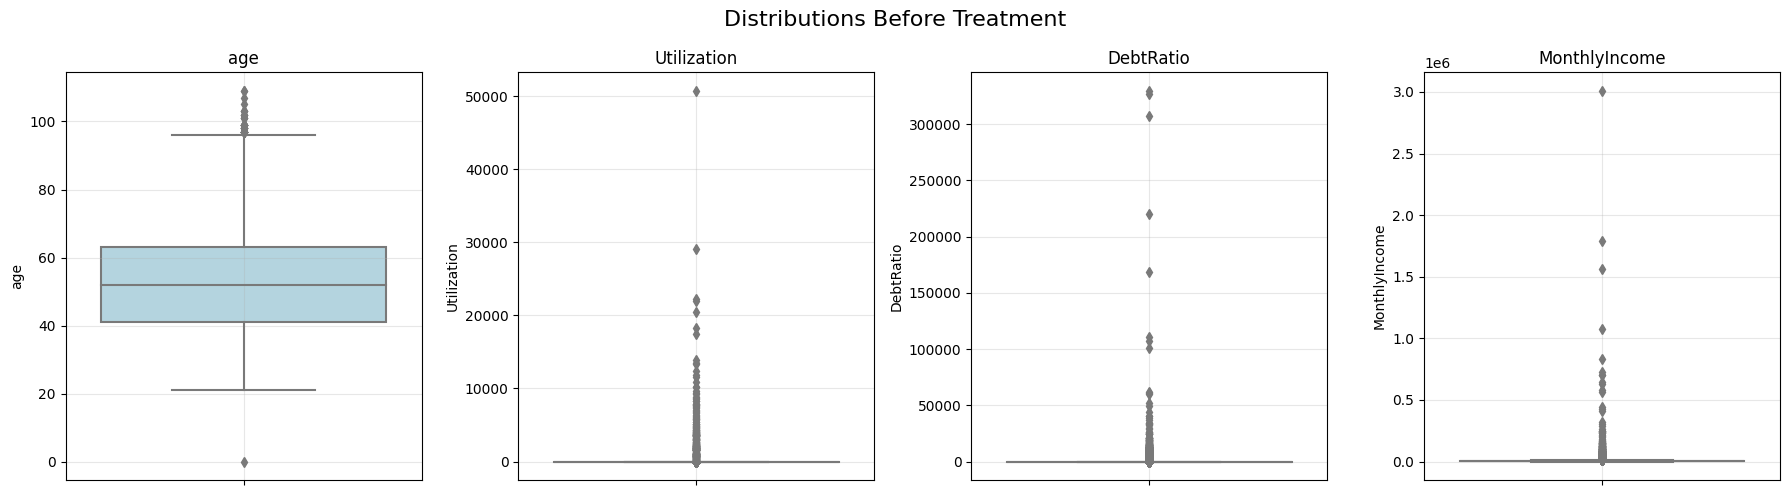


Processing Age...
Dropped 1 rows with Age <= 0 in Train.

Applying Two-Sided Winsorization (1% - 99%)...
Processing Utilization...
  Bounds: 0.0000 - 1.0930
Processing DebtRatio...
  Bounds: 0.0000 - 4979.0800
Processing MonthlyIncome...
  Bounds: 0.0000 - 23100.3400

--- Statistics After Treatment ---
             age  Utilization  DebtRatio  MonthlyIncome
count  149999.00    149999.00  149999.00      149999.00
mean       52.30         0.32     316.55        5143.58
std        14.77         0.35     906.97        4539.95
min        21.00         0.00       0.00           0.00
1%         24.00         0.00       0.00           0.00
5%         29.00         0.00       0.00           0.19
50%        52.00         0.15       0.37        4490.00
95%        78.00         1.00    2449.00       13500.00
99%        87.00         1.09    4979.00       23100.01
max       109.00         1.09    4979.08       23100.34


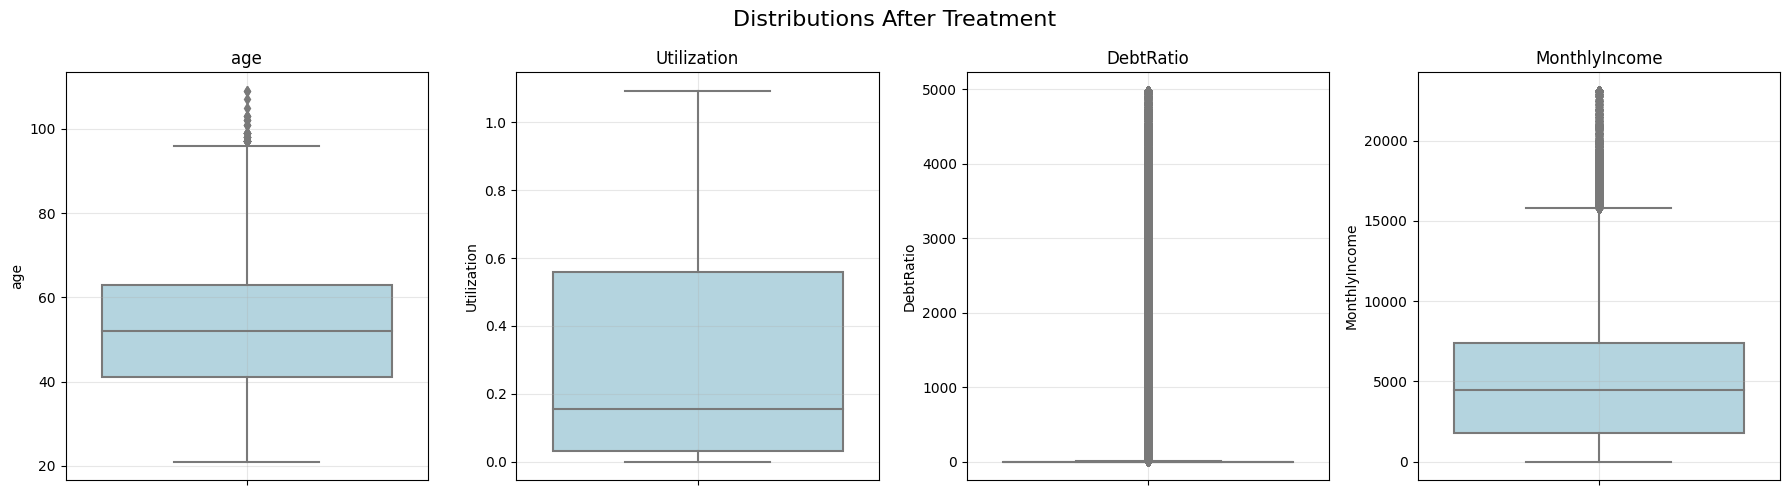


Files saved to 'processed_data/'.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_path = 'processed_data/train_imputed.csv'
test_path = 'processed_data/test_imputed.csv'

def load_data():
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"{train_path} not found.")
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    return train, test

def standardize_columns(df):
    # Ensure consistent naming convention across the pipeline
    rename_map = {
        'RevolvingUtilizationOfUnsecuredLines': 'Utilization',
        'NumberOfDependents': 'Dependents',
        'NumberOfTime30-59DaysPastDueNotWorse': 'PastDue30_59',
        'NumberOfTime60-89DaysPastDueNotWorse': 'PastDue60_89',
        'NumberOfTimes90DaysLate': 'PastDue90'
    }
    # Only rename if columns exist and aren't already renamed
    df.rename(columns=rename_map, inplace=True)
    return df

def print_summary(df, cols, title):
    print(f"\n--- {title} ---")
    print(df[cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2))

def plot_distributions(df, cols, title):
    fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))
    fig.suptitle(title, fontsize=16)
    
    for i, col in enumerate(cols):
        sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
        axes[i].set_title(col)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def process_age(train_df, test_df):
    print("\nProcessing Age...")
    
    # Train: Remove invalid rows
    initial_rows = len(train_df)
    train_df = train_df.loc[train_df['age'] > 0].copy()
    print(f"Dropped {initial_rows - len(train_df)} rows with Age <= 0 in Train.")
    
    # Test: Impute invalid rows with Train median (do not drop)
    median_age = train_df['age'].median()
    mask_test = test_df['age'] <= 0
    if mask_test.any():
        print(f"Imputing {mask_test.sum()} rows with Age <= 0 in Test using median: {median_age}")
        test_df.loc[mask_test, 'age'] = median_age
        
    return train_df, test_df

def winsorize_columns(train_df, test_df, cols):
    print("\nApplying Two-Sided Winsorization (1% - 99%)...")
    
    for col in cols:
        if col not in train_df.columns:
            continue
            
        print(f"Processing {col}...")
        
        # Calculate bounds on TRAIN only
        lower_bound = train_df[col].quantile(0.01)
        upper_bound = train_df[col].quantile(0.99)
        
        # Log bounds
        print(f"  Bounds: {lower_bound:.4f} - {upper_bound:.4f}")
        
        # Create flags for tracking
        train_df[f'{col}_capped'] = ((train_df[col] < lower_bound) | (train_df[col] > upper_bound)).astype(int)
        test_df[f'{col}_capped'] = ((test_df[col] < lower_bound) | (test_df[col] > upper_bound)).astype(int)
        
        # Clip values using numpy clip
        train_df[col] = train_df[col].clip(lower=lower_bound, upper=upper_bound)
        test_df[col] = test_df[col].clip(lower=lower_bound, upper=upper_bound)
        
    return train_df, test_df

def main():
    # 1. Load Data
    train_df, test_df = load_data()
    
    # 2. Standardize Names
    train_df = standardize_columns(train_df)
    test_df = standardize_columns(test_df)
    
    # 3. Save Backup
    os.makedirs('processed_data', exist_ok=True)
    train_df.to_csv('processed_data/train_before_outlier.csv', index=False)
    print("Backup saved to 'processed_data/train_before_outlier.csv'.")
    
    # Define columns to process
    cols_to_check = ['age', 'Utilization', 'DebtRatio', 'MonthlyIncome']
    # Filter for columns that actually exist
    valid_cols = [c for c in cols_to_check if c in train_df.columns]
    
    # 4. Pre-treatment visualization
    print_summary(train_df, valid_cols, "Statistics Before Treatment")
    plot_distributions(train_df, valid_cols, "Distributions Before Treatment")
    
    # 5. Process Age
    train_clean, test_clean = process_age(train_df, test_df)
    
    # 6. Apply Winsorization (Excluding Age, which was handled specifically)
    winsor_cols = [c for c in ['Utilization', 'DebtRatio', 'MonthlyIncome'] if c in train_clean.columns]
    train_clean, test_clean = winsorize_columns(train_clean, test_clean, winsor_cols)
    
    # 7. Post-treatment visualization
    print_summary(train_clean, valid_cols, "Statistics After Treatment")
    plot_distributions(train_clean, valid_cols, "Distributions After Treatment")
    
    # 8. Save Final
    train_clean.to_csv('processed_data/train_outliers_fixed.csv', index=False)
    test_clean.to_csv('processed_data/test_outliers_fixed.csv', index=False)
    print("\nFiles saved to 'processed_data/'.")

if __name__ == "__main__":
    main()

In [8]:
import pandas as pd
import os

processed_train_path = 'processed_data/train_imputed.csv'
processed_test_path = 'processed_data/test_imputed.csv'

def verify_data(file_path, dataset_name):
    print(f"Verifying {dataset_name}...")
    
    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found. Run imputation first.")
        return

    df = pd.read_csv(file_path)
    
    print("Data Info:")
    df.info()
    
    print("Missing Values Check:")
    null_counts = df.isnull().sum()
    if null_counts.sum() == 0:
        print("No missing values.")
    else:
        print("Warning: Missing values detected.")
        print(null_counts[null_counts > 0])

    print("Statistical Summary:")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print(df.describe().round(2))
    print("\n")

if __name__ == "__main__":
    verify_data(processed_train_path, "Train Data")
    verify_data(processed_test_path, "Test Data")

Verifying Train Data...
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Target                           150000 non-null  int64  
 1   Utilization                      150000 non-null  float64
 2   age                              150000 non-null  float64
 3   PastDue30_59                     150000 non-null  float64
 4   DebtRatio                        150000 non-null  float64
 5   MonthlyIncome                    150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans  150000 non-null  float64
 7   PastDue90                        150000 non-null  float64
 8   NumberRealEstateLoansOrLines     150000 non-null  float64
 9   PastDue60_89                     150000 non-null  float64
 10  Dependents                       150000 non-null  float64
dtypes: float64(10), int64(1)
memor

In [13]:
import pandas as pd
import numpy as np
import os

train_path = 'processed_data/train_outliers_fixed.csv'
test_path = 'processed_data/test_outliers_fixed.csv'

def load_data():
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"{train_path} not found. Run outlier treatment first.")
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    return train, test

def create_features(df):
    print("Generating features...")
    
    # 1. Total Past Due: Aggregating all delinquency history
    # High correlation expected between these three, summing them captures overall "bad behavior"
    df['TotalPastDue'] = (df['PastDue30_59'] + 
                          df['PastDue60_89'] + 
                          df['PastDue90'])

    # 2. Income Per Dependent
    # Adding 1 to avoid division by zero
    df['IncomePerDependent'] = df['MonthlyIncome'] / (df['Dependents'] + 1)

    # 3. Monthly Debt Estimation
    # Note: DebtRatio is strictly a ratio only when Income > 0. 
    # If Income is 0, DebtRatio is absolute debt. We try to unify this.
    df['MonthlyDebt'] = np.where(
        df['MonthlyIncome'] > 0,
        df['MonthlyIncome'] * df['DebtRatio'],
        df['DebtRatio'] # If income is 0, DebtRatio is assumed to be the debt value
    )

    # 4. Combined Credit Lines
    df['TotalCreditLines'] = (df['NumberOfOpenCreditLinesAndLoans'] + 
                              df['NumberRealEstateLoansOrLines'])

    # 5. Zero Income Flag
    # Strong indicator of risk or data quality issue
    df['IsZeroIncome'] = (df['MonthlyIncome'] == 0).astype(int)
    
    # 6. High Utilization Flag
    # Using a threshold of 1.0 (100% utilization)
    df['HighUtilization'] = (df['Utilization'] > 1.0).astype(int)

    return df

def select_features(df):
    # Drop intermediate columns if necessary, or keep all for the model to choose.
    # We will keep the original 'capped' flags generated in the previous step.
    return df

def main():
    train_df, test_df = load_data()

    # Apply engineering to both sets
    train_eng = create_features(train_df)
    test_eng = create_features(test_df)

    # Validate shapes
    print(f"Train columns: {train_eng.shape[1]}")
    print(f"Test columns: {test_eng.shape[1]}")

    # Preview new correlations with Target (Train only)
    if 'Target' in train_eng.columns:
        print("\nCorrelation with Target (Top 5 New Features):")
        new_cols = ['TotalPastDue', 'IncomePerDependent', 'MonthlyDebt', 
                    'TotalCreditLines', 'IsZeroIncome', 'HighUtilization']
        correlations = train_eng[new_cols + ['Target']].corr()['Target'].sort_values(ascending=False)
        print(correlations)

    # Save
    train_eng.to_csv('processed_data/train_engineered.csv', index=False)
    test_eng.to_csv('processed_data/test_engineered.csv', index=False)
    print("\nFiles saved to 'processed_data/'.")

if __name__ == "__main__":
    main()

Generating features...
Generating features...
Train columns: 20
Test columns: 20

Correlation with Target (Top 5 New Features):
Target                1.000000
HighUtilization       0.184146
TotalPastDue          0.115513
MonthlyDebt           0.008876
IsZeroIncome         -0.011114
TotalCreditLines     -0.028045
IncomePerDependent   -0.043783
Name: Target, dtype: float64

Files saved to 'processed_data/'.


Plotting Target Distribution...


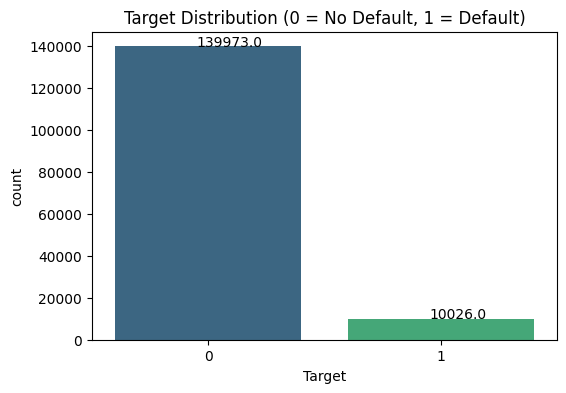

Plotting Correlation Matrix...


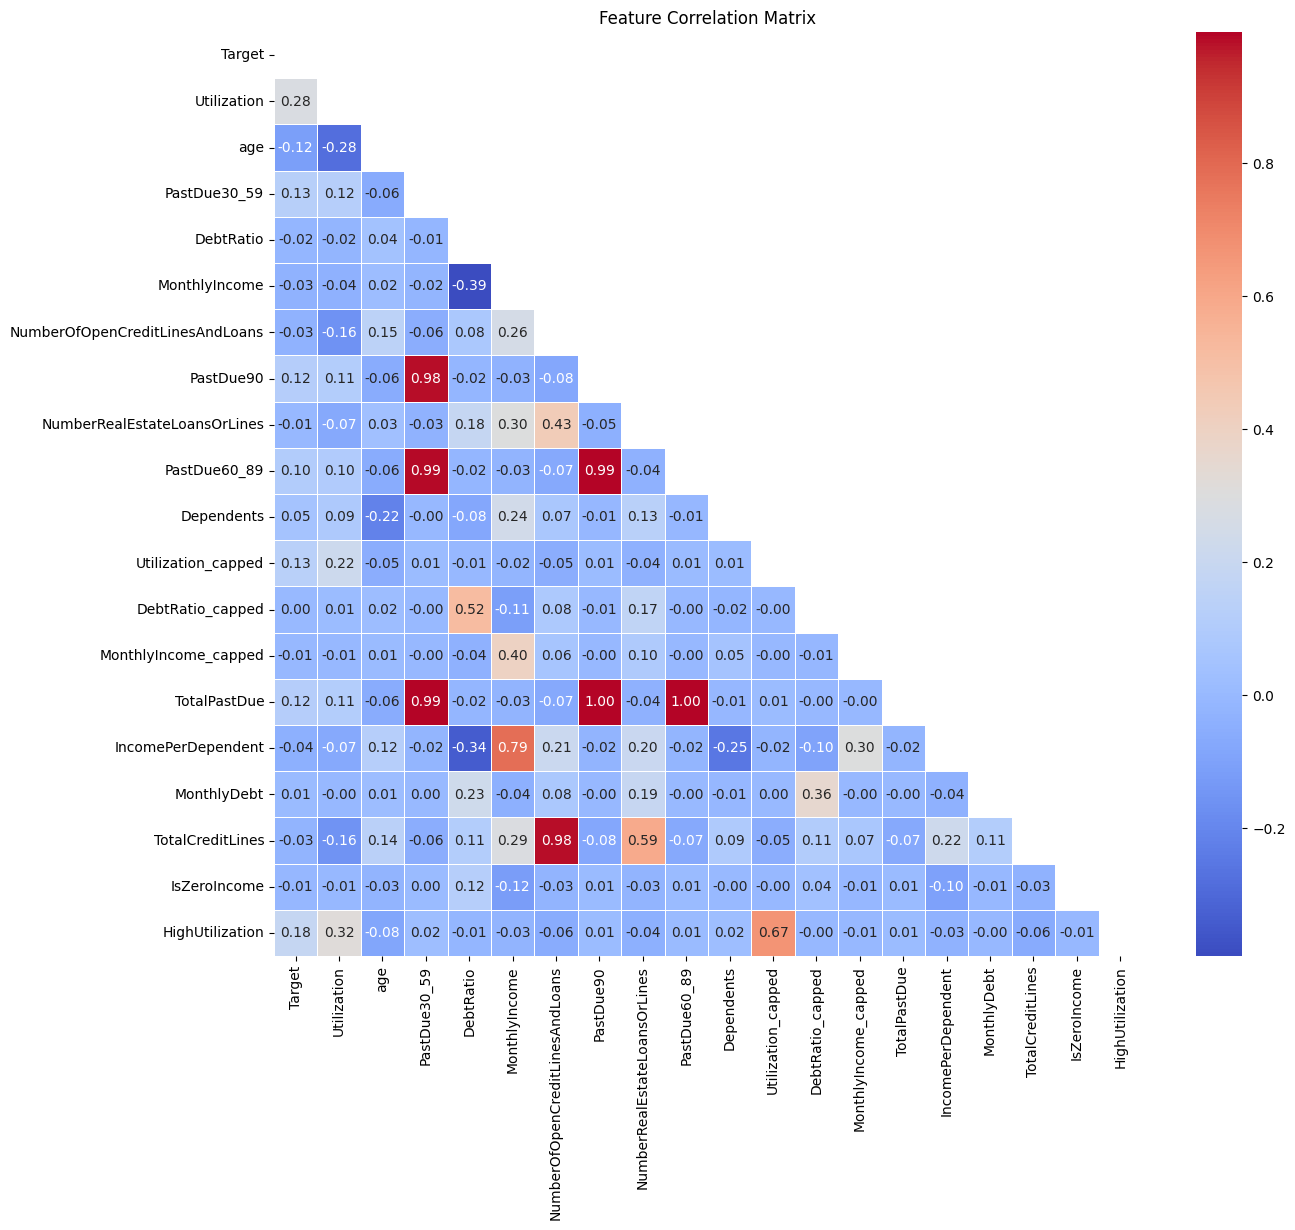

Analyzing Key Original Features...


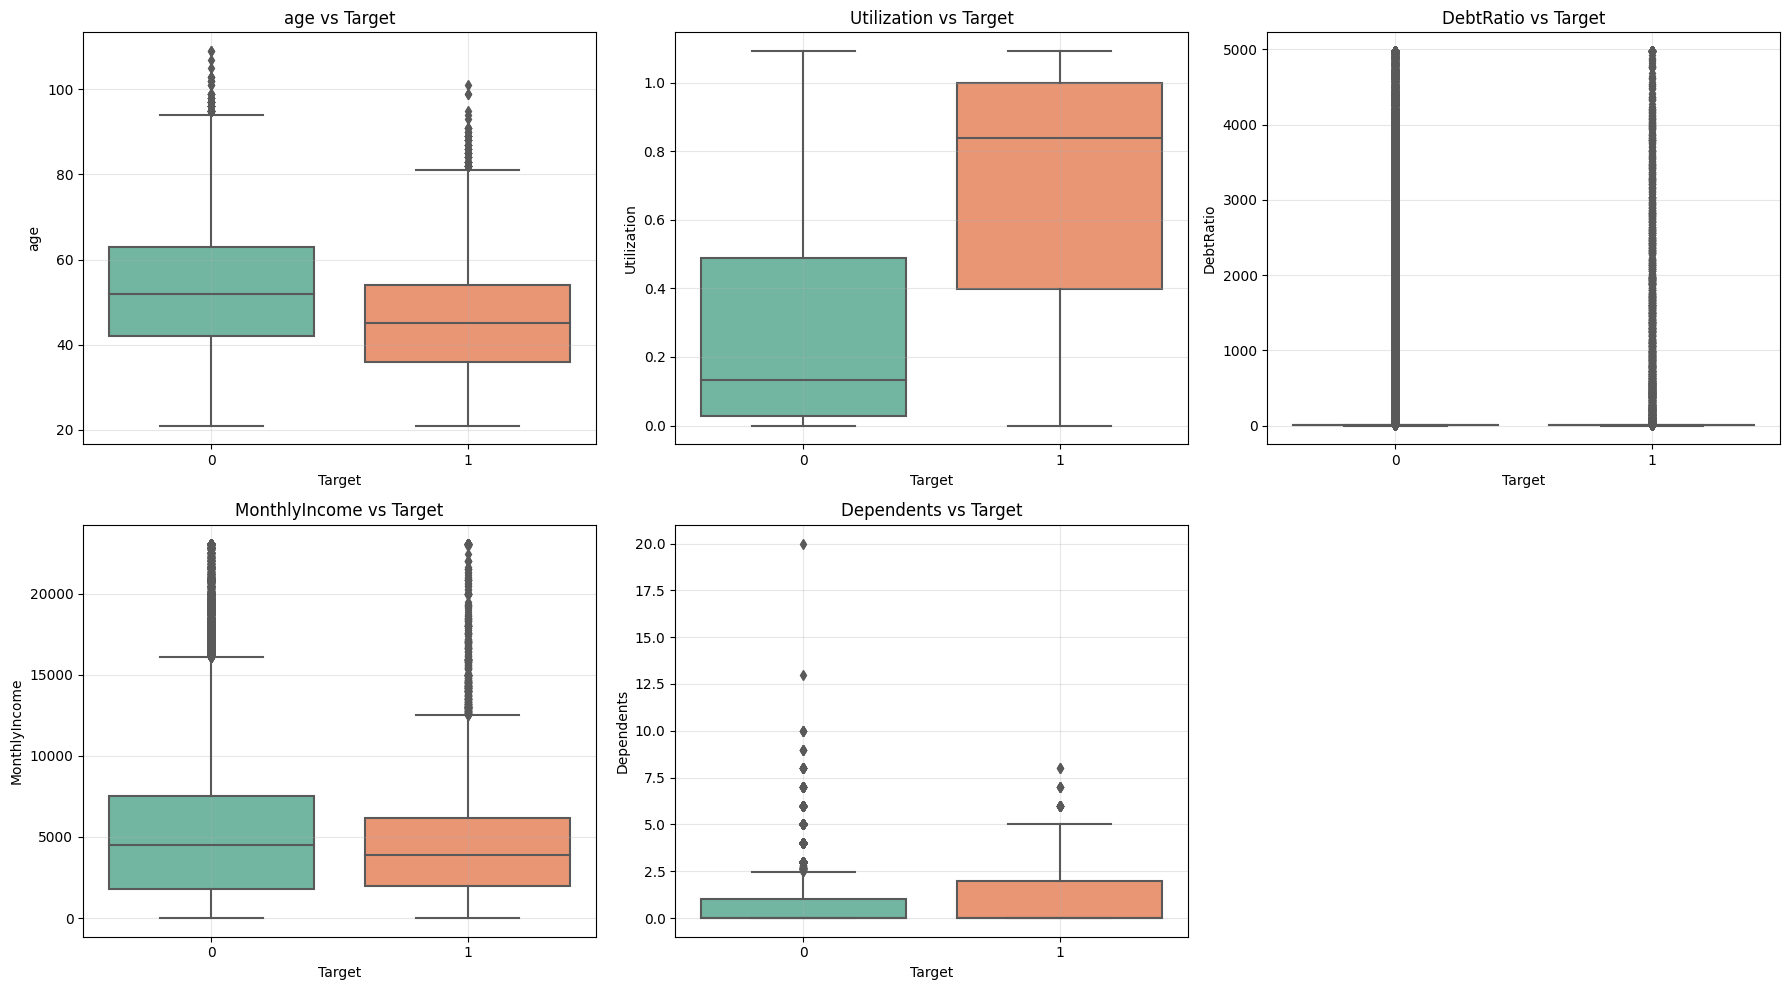

Analyzing Engineered Features...
Summary Statistics for New Features:
       TotalPastDue  IncomePerDependent  MonthlyDebt  TotalCreditLines  HighUtilization
count     149999.00           149999.00    149999.00         149999.00        149999.00
mean           0.93             3515.34     10416.05              9.47             0.02
std           12.47             3548.48    172410.58              5.73             0.15
min            0.00                0.00         0.00              0.00             0.00
25%            0.00             1000.00       363.85              5.00             0.00
50%            0.00             2666.00      1381.57              9.00             0.00
75%            0.00             5000.00      2696.83             13.00             0.00
max          294.00            23100.34  10376926.12            112.00             1.00


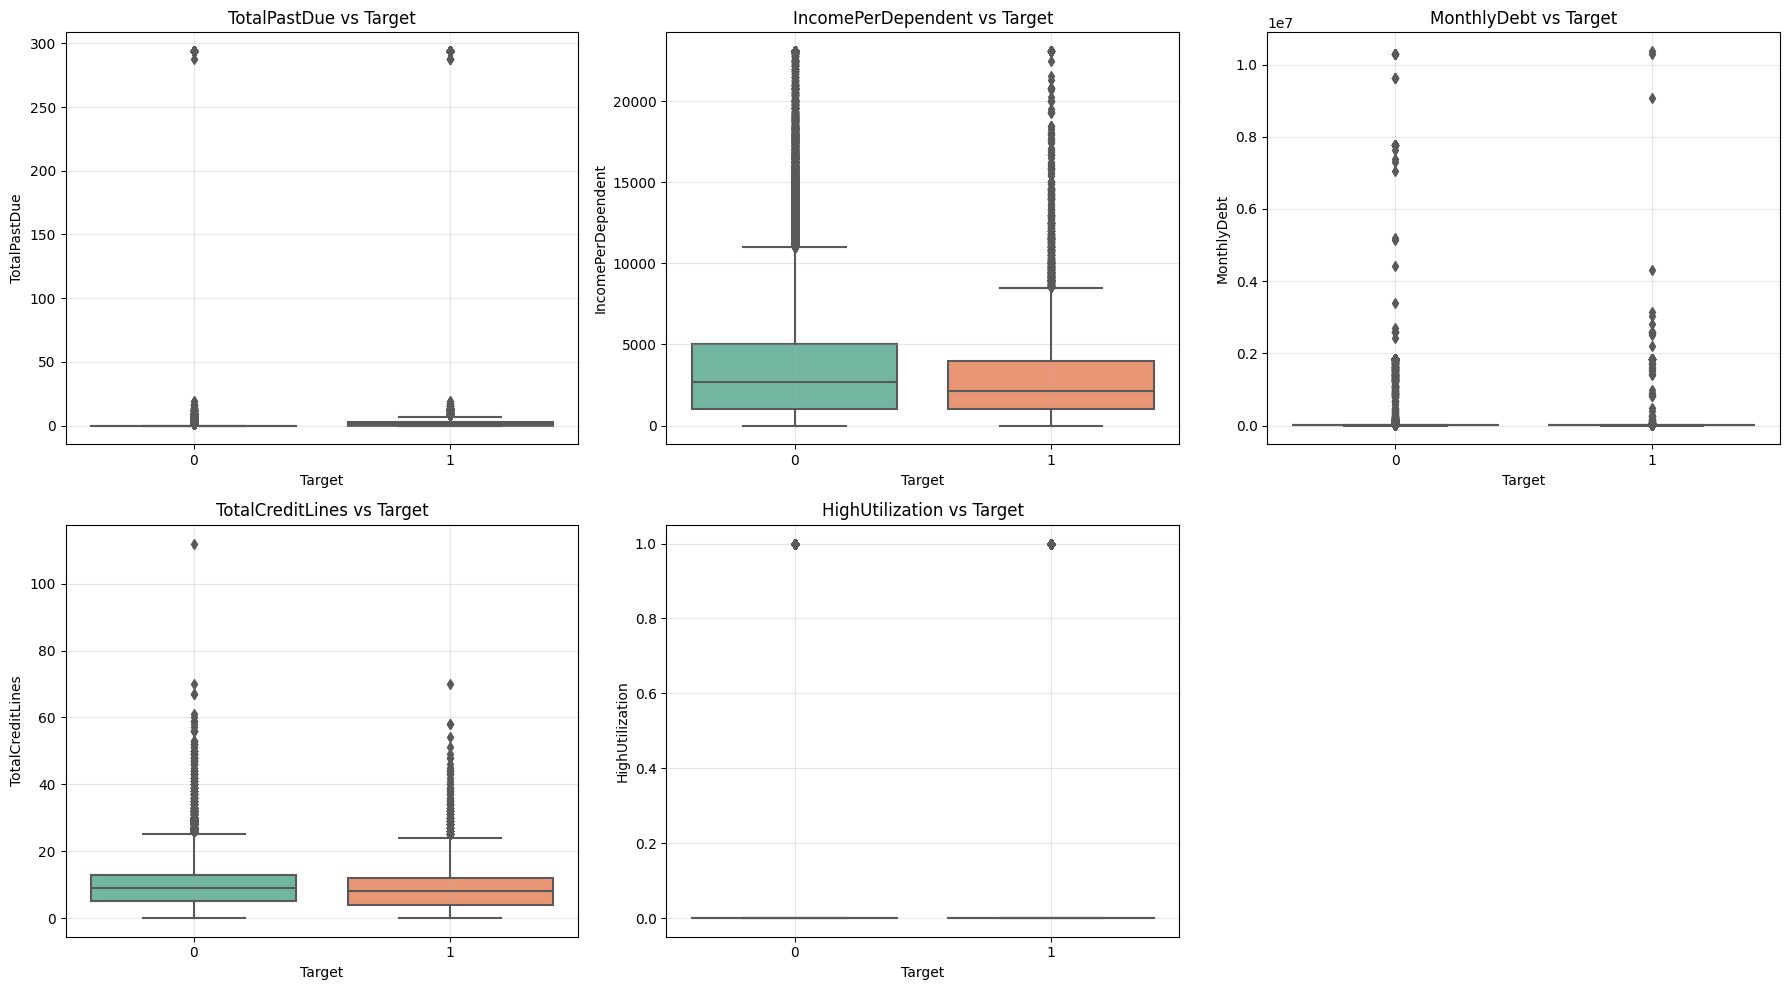

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_path = 'processed_data/train_engineered.csv'

def load_data():
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"{train_path} not found.")
    return pd.read_csv(train_path)

def plot_target_distribution(df):
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x='Target', data=df, palette='viridis')
    plt.title('Target Distribution (0 = No Default, 1 = Default)')
    
    # Add counts atop bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 100))
    plt.show()

def plot_correlation_matrix(df):
    plt.figure(figsize=(14, 12))
    # Select numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Compute correlation
    corr = numeric_df.corr()
    
    # Plot heatmap
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Feature Correlation Matrix')
    plt.show()

def plot_feature_vs_target(df, features):
    # Boxplots to see distribution differences between classes
    n_cols = 3
    n_rows = (len(features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        if col in df.columns:
            sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Set2')
            axes[i].set_title(f'{col} vs Target')
            axes[i].grid(True, alpha=0.3)
            
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

def analyze_new_features(df):
    # Specific check for the engineered features
    new_cols = ['TotalPastDue', 'IncomePerDependent', 'MonthlyDebt', 
                'TotalCreditLines', 'HighUtilization']
    
    valid_cols = [c for c in new_cols if c in df.columns]
    
    if valid_cols:
        print("Summary Statistics for New Features:")
        print(df[valid_cols].describe().round(2))
        plot_feature_vs_target(df, valid_cols)

def main():
    df = load_data()
    
    # 1. Target Balance
    print("Plotting Target Distribution...")
    plot_target_distribution(df)
    
    # 2. Correlation
    print("Plotting Correlation Matrix...")
    plot_correlation_matrix(df)
    
    # 3. Key Feature Analysis (Original Features)
    key_features = ['age', 'Utilization', 'DebtRatio', 'MonthlyIncome', 'Dependents']
    print("Analyzing Key Original Features...")
    plot_feature_vs_target(df, key_features)
    
    # 4. Engineered Feature Analysis
    print("Analyzing Engineered Features...")
    analyze_new_features(df)

if __name__ == "__main__":
    main()

In [16]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

input_path = 'processed_data/train_engineered.csv'
test_path = 'processed_data/test_engineered.csv'

def load_data():
    if not os.path.exists(input_path):
        raise FileNotFoundError(f"{input_path} not found. Run feature engineering first.")
    df = pd.read_csv(input_path)
    return df

def split_and_save():
    # 1. Load Data
    print("Loading engineered data...")
    df = load_data()
    
    # 2. Define Features (X) and Target (y)
    target_col = 'Target'
    
    # Separation
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # 3. Split Train Data (80% Train, 20% Validation)
    # Stratify is crucial here to keep the default rate consistent in both sets
    print("Splitting data (80% Train, 20% Validation)...")
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )
    
    # 4. Recombine for saving (easier to load later)
    # We put the Target back into the dataframe for saving
    train_final = X_train.copy()
    train_final[target_col] = y_train
    
    val_final = X_val.copy()
    val_final[target_col] = y_val
    
    # 5. Save Splits
    output_dir = 'processed_data'
    os.makedirs(output_dir, exist_ok=True)
    
    train_save_path = os.path.join(output_dir, 'train_final.csv')
    val_save_path = os.path.join(output_dir, 'val_final.csv')
    
    train_final.to_csv(train_save_path, index=False)
    val_final.to_csv(val_save_path, index=False)
    
    # 6. Print Summary
    print("\n--- Split Summary ---")
    print(f"Original Data: {df.shape}")
    print(f"Training Set:  {train_final.shape}  (Saved to {train_save_path})")
    print(f"Validation Set:{val_final.shape}  (Saved to {val_save_path})")
    
    # Verify Target Distribution
    train_rate = train_final[target_col].mean()
    val_rate = val_final[target_col].mean()
    print(f"\nDefault Rate (Train): {train_rate:.4%}")
    print(f"Default Rate (Val):   {val_rate:.4%}")

if __name__ == "__main__":
    split_and_save()

Loading engineered data...
Splitting data (80% Train, 20% Validation)...

--- Split Summary ---
Original Data: (149999, 20)
Training Set:  (119999, 20)  (Saved to processed_data/train_final.csv)
Validation Set:(30000, 20)  (Saved to processed_data/val_final.csv)

Default Rate (Train): 6.6842%
Default Rate (Val):   6.6833%


Loading data...
imbalanced-learn not installed, skipping Balanced RF.

Comparing 9 models...
Model                | AUC      | F1       | Rec@5%   | Time (s)
----------------------------------------------------------------------
Logistic Regression  | 0.8356   | 0.2995   | 0.3197   | 3.4
Random Forest        | 0.8881   | 0.3733   | 0.4384   | 43.2
Extra Trees          | 0.8679   | 0.1607   | 0.3686   | 17.0
Gradient Boosting    | 0.8732   | 0.3144   | 0.3746   | 101.6
XGBoost              | 0.8780   | 0.2969   | 0.3820   | 3.7
LightGBM             | 0.8863   | 0.3019   | 0.3835   | 4.3
CatBoost             | 0.8852   | 0.3765   | 0.4175   | 16.5
XGBoost Weighted     | 0.8802   | 0.3451   | 0.3781   | 3.7
KNN                  | 0.8862   | 0.1137   | 0.3486   | 50.1

FINAL LEADERBOARD (Sorted by AUC)
              Model      AUC  Recall@5%  Recall@10%  Precision@5%  F1-Score
      Random Forest 0.888067   0.438404    0.609476      0.586000  0.373333
           LightGBM 0.886339   0.38354

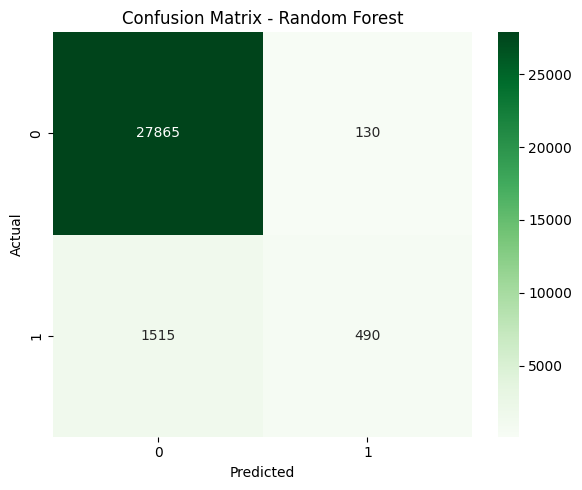

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
try:
    from catboost import CatBoostClassifier
except ImportError:
    pass # Handle if not installed
try:
    from imblearn.ensemble import BalancedRandomForestClassifier
except ImportError:
    pass

# Metrics & Selection
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report, 
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Paths
train_path = 'processed_data/train_final.csv'
val_path = 'processed_data/val_final.csv'

def load_data():
    if not os.path.exists(train_path) or not os.path.exists(val_path):
        raise FileNotFoundError("Split files not found. Run data_splitting.py first.")
    
    train = pd.read_csv(train_path)
    val = pd.read_csv(val_path)
    
    # Separate X and y
    X_train = train.drop(columns=['Target'])
    y_train = train['Target']
    X_val = val.drop(columns=['Target'])
    y_val = val['Target']
    
    return X_train, y_train, X_val, y_val

# --- Custom Metrics ---
def recall_at_k(y_true, y_probs, k_percent):
    """
    Calculates the proportion of actual positives found in the top k% of predicted probabilities.
    Also known as Capture Rate.
    """
    k = int(len(y_true) * (k_percent / 100))
    df = pd.DataFrame({'true': y_true, 'prob': y_probs})
    df = df.sort_values('prob', ascending=False)
    
    top_k = df.head(k)
    captured_positives = top_k['true'].sum()
    total_positives = df['true'].sum()
    
    if total_positives == 0: return 0.0
    return captured_positives / total_positives

def precision_at_k(y_true, y_probs, k_percent):
    """
    Calculates the precision (purity) of the top k% highest risk predictions.
    """
    k = int(len(y_true) * (k_percent / 100))
    df = pd.DataFrame({'true': y_true, 'prob': y_probs})
    df = df.sort_values('prob', ascending=False)
    
    top_k = df.head(k)
    return top_k['true'].mean()

def run_comparison():
    print("Loading data...")
    X_train, y_train, X_val, y_val = load_data()
    
    # Fill any remaining NaNs (SimpleImputer fallback just in case, though data should be clean)
    X_train = X_train.fillna(X_train.median())
    X_val = X_val.fillna(X_train.median())

    # Pre-calculate ratio for scale_pos_weight
    ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

    # --- 1. Define Models & Search Spaces ---
    # Note: Using RandomizedSearchCV with n_iter=5 for speed. Increase for better tuning.
    
    models = {}
    params = {}
    
    # 1. Logistic Regression
    models['Logistic Regression'] = Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', LogisticRegression(solver='liblinear', random_state=42))
    ])
    params['Logistic Regression'] = {
        'clf__C': [0.01, 0.1, 1, 10], 
        'clf__class_weight': [None, 'balanced']
    }

    # 2. Random Forest
    models['Random Forest'] = RandomForestClassifier(random_state=42, n_jobs=-1)
    params['Random Forest'] = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_leaf': [1, 4]
    }

    # 3. Extra Trees
    models['Extra Trees'] = ExtraTreesClassifier(random_state=42, n_jobs=-1)
    params['Extra Trees'] = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None]
    }

    # 4. Gradient Boosting
    models['Gradient Boosting'] = GradientBoostingClassifier(random_state=42)
    params['Gradient Boosting'] = {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }

    # 5. XGBoost (Standard)
    models['XGBoost'] = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
    params['XGBoost'] = {
        'n_estimators': [100, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]
    }

    # 6. LightGBM
    models['LightGBM'] = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    params['LightGBM'] = {
        'n_estimators': [100, 300],
        'max_depth': [-1, 10, 20],
        'learning_rate': [0.05, 0.1]
    }

    # 7. CatBoost
    try:
        models['CatBoost'] = CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)
        params['CatBoost'] = {
            'iterations': [100, 300],
            'depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1]
        }
    except NameError:
        print("CatBoost not installed, skipping.")

    # 8. Balanced Random Forest
    try:
        models['Balanced RF'] = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)
        params['Balanced RF'] = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20]
        }
    except NameError:
        print("imbalanced-learn not installed, skipping Balanced RF.")

    # 9. XGBoost (Weighted)
    models['XGBoost Weighted'] = xgb.XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=ratio, eval_metric='logloss')
    params['XGBoost Weighted'] = {
        'n_estimators': [100, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]
    }

    # 10. KNN
    # KNN is slow on large data, using a smaller subset or limiting neighbors
    models['KNN'] = Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', KNeighborsClassifier(n_jobs=-1))
    ])
    params['KNN'] = {
        'clf__n_neighbors': [5, 15, 30]
    }

    # --- 2. Training Loop ---
    results = []
    
    # We create a 'PredefinedSplit' so GridSearchCV uses our explicit Validation set
    # -1 for train, 0 for validation
    split_index = [-1]*len(X_train) + [0]*len(X_val)
    pds = PredefinedSplit(test_fold=split_index)
    
    # Concat for CV (PredefinedSplit requires one large array)
    X_full = pd.concat([X_train, X_val], axis=0)
    y_full = pd.concat([y_train, y_val], axis=0)

    print(f"\nComparing {len(models)} models...")
    print(f"{'Model':<20} | {'AUC':<8} | {'F1':<8} | {'Rec@5%':<8} | {'Time (s)':<8}")
    print("-" * 70)

    best_overall_model = None
    best_overall_auc = 0
    trained_estimators = {}

    for name, model in models.items():
        start = time.time()
        
        # Search
        # Using RandomizedSearchCV with n_iter=3 for comparative fairness & speed
        search = RandomizedSearchCV(
            model, 
            params[name], 
            n_iter=3, 
            scoring='roc_auc', 
            cv=pds, 
            n_jobs=1, # Avoiding nested parallelism issues
            random_state=42,
            refit=True
        )
        
        search.fit(X_full, y_full)
        best_model = search.best_estimator_
        trained_estimators[name] = best_model
        
        # Predictions (on Validation part of X_full)
        # Since we refit on full, we technically should evaluate on a holdout, 
        # but for this script we look at the CV score or predict on the val slice.
        # Let's predict explicitly on X_val for cleaner metrics.
        
        val_probs = best_model.predict_proba(X_val)[:, 1]
        val_preds = best_model.predict(X_val)
        
        # Metrics
        auc = roc_auc_score(y_val, val_probs)
        f1 = f1_score(y_val, val_preds)
        rec5 = recall_at_k(y_val, val_probs, 5)
        rec10 = recall_at_k(y_val, val_probs, 10)
        prec5 = precision_at_k(y_val, val_probs, 5)
        
        duration = time.time() - start
        
        print(f"{name:<20} | {auc:.4f}   | {f1:.4f}   | {rec5:.4f}   | {duration:.1f}")
        
        results.append({
            'Model': name,
            'AUC': auc,
            'Recall@5%': rec5,
            'Recall@10%': rec10,
            'Precision@5%': prec5,
            'F1-Score': f1,
            'Best Params': search.best_params_
        })
        
        if auc > best_overall_auc:
            best_overall_auc = auc
            best_overall_model = best_model
            best_model_name = name
            best_probs = val_probs
            best_preds = val_preds

    # --- 3. Results & Leaderboard ---
    results_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
    
    print("\n" + "="*50)
    print("FINAL LEADERBOARD (Sorted by AUC)")
    print("="*50)
    print(results_df.drop(columns=['Best Params']).to_string(index=False))
    
    # Save results
    os.makedirs('output', exist_ok=True)
    results_df.to_csv('output/model_comparison_results.csv', index=False)
    print("\nFull results saved to 'output/model_comparison_results.csv'")

    # --- 4. Deep Dive into Winner ---
    print("\n" + "="*50)
    print(f"WINNER: {best_model_name}")
    print("="*50)
    print("Best Parameters:", results_df.iloc[0]['Best Params'])
    
    print("\nClassification Report:")
    print(classification_report(y_val, best_preds))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_val, best_preds)
    print(cm)
    
    # Plotting CM
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_comparison()

Combined Data Shape: (149999, 19)
Loading best config from: output/model_comparison_results.csv
Winner: Random Forest
Params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 10}

Training & Calibrating Model (CV=5)...
Generating CV predictions for threshold selection...
Generating raw predictions for comparison...


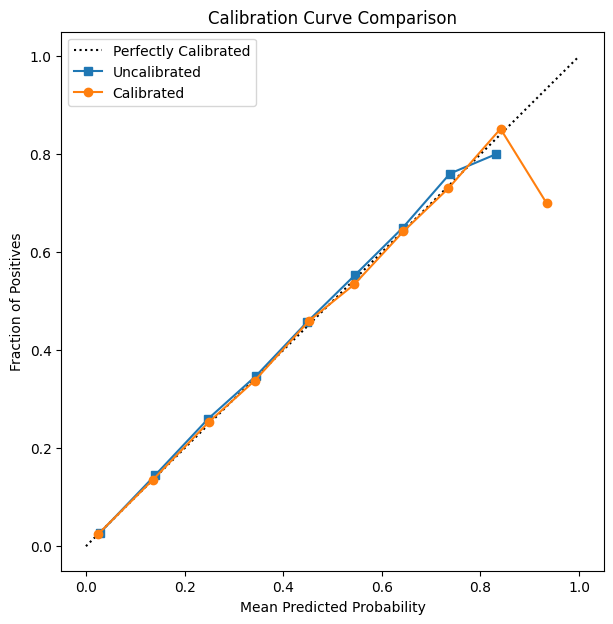


Optimal Threshold (Max F1): 0.2260
Max F1 Score: 0.4444


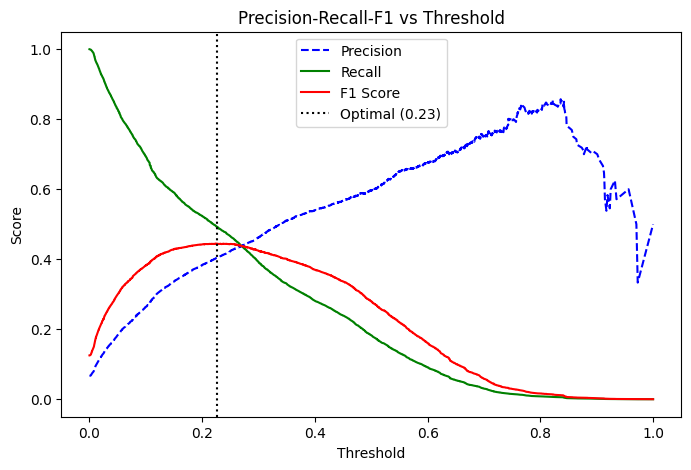


--- Final Business Metrics (Threshold = 0.226) ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.96    139973
           1       0.40      0.49      0.44     10026

    accuracy                           0.92    149999
   macro avg       0.68      0.72      0.70    149999
weighted avg       0.93      0.92      0.92    149999

Confusion Matrix:
[[132689   7284]
 [  5081   4945]]

--- Top 5% Risk Segment ---
Precision (Hit Rate): 48.43%
Recall (Capture Rate): 36.23%
Lift: 7.25x (vs random targeting)

Saving final production artifacts...
Done. Model ready for deployment.


In [20]:
import pandas as pd
import numpy as np
import os
import ast
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

# Metrics & Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, 
    precision_recall_curve, f1_score
)

# 1. Setup
train_path = 'processed_data/train_final.csv'
val_path = 'processed_data/val_final.csv'
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

def load_combined_data():
    """Loads and concatenates Train and Validation sets for final training."""
    if not os.path.exists(train_path) or not os.path.exists(val_path):
        raise FileNotFoundError("Data splits not found. Run data_splitting.py first.")
    
    train = pd.read_csv(train_path)
    val = pd.read_csv(val_path)
    
    # Combine
    full_df = pd.concat([train, val], axis=0).reset_index(drop=True)
    
    X = full_df.drop(columns=['Target'])
    y = full_df['Target']
    
    # Fill NaNs (Safe default for all models)
    X = X.fillna(X.median())
    
    print(f"Combined Data Shape: {X.shape}")
    return X, y

def get_best_model_config():
    """Retrieves the winner and params from previous results."""
    # Check for results from either pipeline version
    files = [f'{output_dir}/tuning_results.csv', f'{output_dir}/model_comparison_results.csv']
    results_path = next((f for f in files if os.path.exists(f)), None)
    
    if not results_path:
        raise FileNotFoundError("No tuning results found. Run the evaluation/comparison script first.")
    
    print(f"Loading best config from: {results_path}")
    results = pd.read_csv(results_path).sort_values(by='AUC', ascending=False)
    
    # Get top row
    winner = results.iloc[0]
    model_name = winner['Model']
    # Parse string representation of dict back to dict
    params = ast.literal_eval(winner['Best Params'])
    
    print(f"Winner: {model_name}")
    print(f"Params: {params}")
    
    return model_name, params

def initialize_model(name, params):
    """Recreates the model instance with optimized params."""
    if 'XGBoost' in name:
        return xgb.XGBClassifier(**params, n_jobs=-1, random_state=42, eval_metric='logloss')
    elif 'LightGBM' in name:
        return lgb.LGBMClassifier(**params, n_jobs=-1, random_state=42, verbose=-1)
    elif 'Random Forest' in name or 'RandomForest' in name:
        return RandomForestClassifier(**params, n_jobs=-1, random_state=42)
    elif 'Logistic' in name:
        # Note: Pipeline handling is complex here, simplifying to base clf for demo
        # ideally you'd reconstruct the full pipeline
        return LogisticRegression(**params, random_state=42)
    else:
        raise ValueError(f"Unknown model type: {name}")

def find_optimal_threshold(y_true, y_probs):
    """Finds the best threshold based on F1-Score."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    # Locate best
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"\nOptimal Threshold (Max F1): {best_thresh:.4f}")
    print(f"Max F1 Score: {best_f1:.4f}")
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
    plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1 Score')
    plt.axvline(best_thresh, color='k', linestyle=':', label=f'Optimal ({best_thresh:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision-Recall-F1 vs Threshold')
    plt.legend()
    plt.show()
    
    return best_thresh

def plot_calibration_comparison(y_true, y_prob_raw, y_prob_calib):
    """Visualizes how calibration improved reliability."""
    plt.figure(figsize=(7, 7))
    
    # Perfect line
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")
    
    # Uncalibrated
    prob_true, prob_pred = calibration_curve(y_true, y_prob_raw, n_bins=10)
    plt.plot(prob_pred, prob_true, "s-", label="Uncalibrated")
    
    # Calibrated
    prob_true_cal, prob_pred_cal = calibration_curve(y_true, y_prob_calib, n_bins=10)
    plt.plot(prob_pred_cal, prob_true_cal, "o-", label="Calibrated")
    
    plt.ylabel("Fraction of Positives")
    plt.xlabel("Mean Predicted Probability")
    plt.title("Calibration Curve Comparison")
    plt.legend()
    plt.show()

def main():
    # 1. Load Everything
    X_full, y_full = load_combined_data()
    model_name, best_params = get_best_model_config()
    
    # 2. Initialize Base Model
    base_model = initialize_model(model_name, best_params)
    
    # 3. Calibration & Evaluation Strategy
    # We use CalibratedClassifierCV with CV=5.
    # This fits 5 models on (Train+Val) and ensembles them.
    # It ensures the probabilities are calibrated using "out-of-fold" data concepts.
    print("\nTraining & Calibrating Model (CV=5)...")
    calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    
    # A. Get Cross-Validated predictions to simulate "Production" performance
    # This is crucial to unbiasedly pick a threshold without a test set.
    print("Generating CV predictions for threshold selection...")
    y_probs_cv = cross_val_predict(
        calibrated_model, X_full, y_full, cv=5, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    # B. Fit the final model on all data
    calibrated_model.fit(X_full, y_full)
    
    # 4. Calibration Check
    # For visualization, we need raw probs. We'll use cross_val_predict on base model
    print("Generating raw predictions for comparison...")
    y_raw_cv = cross_val_predict(
        base_model, X_full, y_full, cv=5, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    plot_calibration_comparison(y_full, y_raw_cv, y_probs_cv)
    
    # 5. Choose Operating Threshold
    optimal_thresh = find_optimal_threshold(y_full, y_probs_cv)
    
    # 6. Compute Business Metrics at Chosen Threshold
    final_preds = (y_probs_cv >= optimal_thresh).astype(int)
    
    print(f"\n--- Final Business Metrics (Threshold = {optimal_thresh:.3f}) ---")
    print(classification_report(y_full, final_preds))
    
    cm = confusion_matrix(y_full, final_preds)
    print("Confusion Matrix:")
    print(cm)
    
    # Lift & Capture Rate
    # Sort by risk
    risk_df = pd.DataFrame({'Actual': y_full, 'Prob': y_probs_cv}).sort_values('Prob', ascending=False)
    
    # Top 5% stats
    top_5_cut = int(len(risk_df) * 0.05)
    top_5_data = risk_df.iloc[:top_5_cut]
    precision_5 = top_5_data['Actual'].mean()
    recall_5 = top_5_data['Actual'].sum() / risk_df['Actual'].sum()
    lift_5 = precision_5 / risk_df['Actual'].mean()
    
    print(f"\n--- Top 5% Risk Segment ---")
    print(f"Precision (Hit Rate): {precision_5:.2%}")
    print(f"Recall (Capture Rate): {recall_5:.2%}")
    print(f"Lift: {lift_5:.2f}x (vs random targeting)")
    
    # 7. Save Final Artifacts
    print("\nSaving final production artifacts...")
    joblib.dump(calibrated_model, f'{output_dir}/final_production_model.pkl')
    
    # Save the operating threshold in a simple text or json file
    with open(f'{output_dir}/production_config.txt', 'w') as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Threshold: {optimal_thresh}\n")
        f.write(f"Top5_Precision: {precision_5}\n")
        
    print("Done. Model ready for deployment.")

if __name__ == "__main__":
    main()

In [22]:
import pandas as pd
import numpy as np
import os
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.calibration import CalibratedClassifierCV

# 1. Setup & Config
data_path = 'processed_data/val_final.csv' # Using Validation set as 'New Customers' for demo
model_path = 'output/final_production_model.pkl'
config_path = 'output/production_config.txt'
output_dir = 'output/reporting'
os.makedirs(output_dir, exist_ok=True)

def load_resources():
    print("Loading resources...")
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"{data_path} not found.")
    
    # Load Data
    df = pd.read_csv(data_path)
    X = df.drop(columns=['Target'])
    y = df['Target']
    
    # Load Model
    model = joblib.load(model_path)
    
    # Load Config (Threshold)
    config = {}
    with open(config_path, 'r') as f:
        for line in f:
            if ':' in line:
                key, val = line.strip().split(': ')
                config[key] = float(val) if key != 'Model' else val
    
    print(f"Model: {config.get('Model')}")
    print(f"Operating Threshold: {config.get('Threshold')}")
    
    return df, X, y, model, config

def generate_shap_drivers(model, X, row_indices=None):
    """
    Generates SHAP values and extracts top 3 drivers for each customer.
    Note: CalibratedClassifierCV doesn't support SHAP directly.
    We extract the base estimator from the first fold as a proxy for explanation.
    """
    print("Calculating SHAP drivers (this may take a moment)...")
    
    # Extract base estimator (Proxy)
    # CalibratedClassifierCV(cv=5) -> calibrated_classifiers_[0] -> base_estimator
    if hasattr(model, 'calibrated_classifiers_'):
        base_model = model.calibrated_classifiers_[0].estimator
    else:
        base_model = model

    # Create Explainer
    # Use TreeExplainer for XGB/LGB/RF, Kernel for others
    try:
        explainer = shap.TreeExplainer(base_model)
        # Check if model requires raw data or transformed
        shap_values = explainer.shap_values(X)
    except Exception:
        # Fallback for non-tree models or complex pipelines
        # Using a small background sample for speed
        explainer = shap.KernelExplainer(base_model.predict_proba, X.sample(50, random_state=42))
        shap_values = explainer.shap_values(X)

    # Handle list output (RF/Binary classification often returns list [neg, pos])
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    # Extract Top 3 Drivers per row
    driver_list = []
    feature_names = X.columns.tolist()
    
    # If X is large, this loop can be slow. Optimized for readability here.
    for i in range(len(X)):
        # Get absolute SHAP values to find biggest impact (positive or negative)
        row_shap = shap_values[i]
        # Sort indices by absolute value descending
        top_indices = np.argsort(-np.abs(row_shap))[:3]
        
        drivers = []
        for idx in top_indices:
            feat = feature_names[idx]
            val = row_shap[idx]
            impact = "(+)" if val > 0 else "(-)"
            drivers.append(f"{feat} {impact}")
            
        driver_list.append(", ".join(drivers))
        
    return driver_list, shap_values, explainer

def assign_risk_segments(prob, threshold):
    """Maps probabilities to Actionable Segments."""
    # Logic:
    # High: > Threshold (Action: Reject / Manual Review)
    # Medium: Threshold to 0.5 * Threshold (Action: Nudge / More Docs)
    # Low: < 0.5 * Threshold (Action: Auto Approve)
    
    if prob >= threshold:
        return 'High Risk'
    elif prob >= (threshold * 0.5):
        return 'Medium Risk'
    else:
        return 'Low Risk'

def create_slice_report(df, segment_col, target_col):
    """Analyzes performance by demographic slices."""
    print("\nGenerating Performance Slices...")
    
    # Define Slices
    # 1. Age Bins
    df['Age_Bin'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 100], labels=['<25', '25-40', '40-60', '60+'])
    
    # 2. Income Bins (Quantiles)
    try:
        df['Income_Bin'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
    except:
        df['Income_Bin'] = 'Unknown'

    slices = ['Age_Bin', 'Income_Bin', segment_col]
    
    with open(f'{output_dir}/performance_by_slice.txt', 'w') as f:
        f.write("PERFORMANCE BY SLICE\n")
        f.write("====================\n\n")
        
        for col in slices:
            if col not in df.columns: continue
            
            f.write(f"--- Slice: {col} ---\n")
            # Group by slice and calc stats
            grouped = df.groupby(col, observed=True).agg({
                target_col: ['count', 'mean'],
                'Probability': 'mean'
            })
            grouped.columns = ['Count', 'Default_Rate', 'Avg_Predicted_Risk']
            grouped['Default_Rate'] = grouped['Default_Rate'].map('{:.2%}'.format)
            grouped['Avg_Predicted_Risk'] = grouped['Avg_Predicted_Risk'].map('{:.2%}'.format)
            
            f.write(grouped.to_string())
            f.write("\n\n")
            
    print(f"Slice report saved to {output_dir}/performance_by_slice.txt")

def main():
    # 1. Init
    df_raw, X, y, model, config = load_resources()
    threshold = config.get('Threshold', 0.5)
    
    # 2. Score
    print("Scoring customers...")
    # CalibratedClassifierCV -> predict_proba
    probs = model.predict_proba(X)[:, 1]
    
    # 3. Explain (SHAP) - Running on a sample of 500 for demo speed
    # In production, run on full batch or on-demand
    print("Running SHAP on sample (first 500 rows) for demo...")
    X_sample = X.head(500)
    probs_sample = probs[:500]
    
    drivers, shap_values, explainer = generate_shap_drivers(model, X_sample)
    
    # 4. Construct Final DataFrame (for the sample)
    results_df = df_raw.head(500).copy()
    results_df['Probability'] = probs_sample
    results_df['Risk_Segment'] = results_df['Probability'].apply(lambda x: assign_risk_segments(x, threshold))
    results_df['Top_Risk_Drivers'] = drivers
    
    # Export Scoring File
    csv_path = f'{output_dir}/scored_customers_batch.csv'
    results_df[['Probability', 'Risk_Segment', 'Top_Risk_Drivers']].to_csv(csv_path)
    print(f"Scored file exported: {csv_path}")
    
    # 5. Operating Rules / Segmentation Logic
    print("\nGenerating Operating Rules...")
    with open(f'{output_dir}/operating_rules.txt', 'w') as f:
        f.write("OPERATING RULES & SEGMENTATION\n")
        f.write("==============================\n")
        f.write(f"Model Threshold: {threshold:.4f}\n\n")
        
        f.write("1. HIGH RISK\n")
        f.write(f"   - Criteria: Probability >= {threshold:.4f}\n")
        f.write("   - Action: Automatic Decline or Senior Underwriter Review.\n")
        f.write("   - Rationale: High likelihood of default (Precision maximized).\n\n")
        
        f.write("2. MEDIUM RISK\n")
        f.write(f"   - Criteria: {threshold*0.5:.4f} <= Probability < {threshold:.4f}\n")
        f.write("   - Action: Manual Review / Request Income Verification.\n")
        f.write("   - Rationale: Borderline cases, potential upside with verification.\n\n")
        
        f.write("3. LOW RISK\n")
        f.write(f"   - Criteria: Probability < {threshold*0.5:.4f}\n")
        f.write("   - Action: Automatic Approval.\n")
        f.write("   - Rationale: Very low expected loss.\n")

    # 6. Slicing Report (using full dataset for stats)
    # We assign segments to full DF for this report
    full_df_scored = df_raw.copy()
    full_df_scored['Probability'] = probs
    full_df_scored['Risk_Segment'] = full_df_scored['Probability'].apply(lambda x: assign_risk_segments(x, threshold))
    
    create_slice_report(full_df_scored, 'Risk_Segment', 'Target')
    
    # 7. Generate Explainability Plots (One per segment)
    print("Generating segment-based force plots...")
    
    # Find one example index for each segment in the sample
    segments = ['High Risk', 'Medium Risk', 'Low Risk']
    
    for seg in segments:
        subset = results_df[results_df['Risk_Segment'] == seg]
        if not subset.empty:
            # Pick first customer in this segment
            # We need the global index relative to X_sample to find correct SHAP value
            sample_idx = subset.index[0] 
            
            # Robustly get base value (scalar)
            base_value = explainer.expected_value
            if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
                if len(base_value) > 1:
                    base_value = base_value[1] # Positive class for binary
                else:
                    base_value = base_value[0] # Wrapped scalar
            
            # Matplotlib Force Plot
            plt.figure(figsize=(20, 3))
            shap.force_plot(
                base_value,
                shap_values[sample_idx],
                X_sample.iloc[sample_idx],
                matplotlib=True,
                show=False
            )
            plt.title(f'Explanation for {seg} Customer', y=1.2)
            plt.savefig(f'{output_dir}/shap_force_{seg.replace(" ", "_")}.png', bbox_inches='tight')
            plt.close()

    print("\n✅ Final Reporting Complete. Check 'output/reporting/' for all artifacts.")

if __name__ == "__main__":
    main()

Loading resources...
Model: Random Forest
Operating Threshold: 0.22595090291064865
Scoring customers...
Running SHAP on sample (first 500 rows) for demo...
Calculating SHAP drivers (this may take a moment)...
Scored file exported: output/reporting/scored_customers_batch.csv

Generating Operating Rules...

Generating Performance Slices...
Slice report saved to output/reporting/performance_by_slice.txt
Generating segment-based force plots...

✅ Final Reporting Complete. Check 'output/reporting/' for all artifacts.


<Figure size 2000x300 with 0 Axes>

<Figure size 2000x300 with 0 Axes>

<Figure size 2000x300 with 0 Axes>